In [15]:
#!/usr/bin/python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Function Library

In [16]:
### FUNCTION LIBRARY ###

def updateInput(filepath, attributes, contrail, type):
    """
    Update the input file with the given attributes.

    Parameters:
    - filepath (str): The path of the input file to be updated.
    - attributes (object): An object containing the attributes to be written to the input file.
    - contrail (bool): A flag indicating whether the input file is for contrail simulation or not.

    Returns:
    None
    """
    file = open(filepath,"w")
    if contrail == True and type == "water":
        file.writelines(["rte_solver "+attributes.rte_solver[0]+"\n",
                            "source "+attributes.source[0]+"\n",
                            "sza "+attributes.sza[0]+"\n",
                            "wavelength "+attributes.wavelength[0]+"\n",
                            "mol_abs_param "+attributes.mol_abs_param[0]+"\n",
                            "umu "+attributes.umu[0]+"\n",
                            "output_user "+attributes.output_user[0]+"\n",
                            "zout "+attributes.zout[0]+"\n",
                            "output_process "+attributes.output_process[0]+"\n",
                            "atmosphere_file "+str(attributes.atmosphere_file[0])+"\n",
                            "wc_file 1D cloud.in\n",
                            "quiet"])
        file.close()
    elif contrail == True and type == "ice":
        file.writelines(["rte_solver "+attributes.rte_solver[0]+"\n",
                            "source "+attributes.source[0]+"\n",
                            "sza "+attributes.sza[0]+"\n",
                            "wavelength "+attributes.wavelength[0]+"\n",
                            "mol_abs_param "+attributes.mol_abs_param[0]+"\n",
                            "umu "+attributes.umu[0]+"\n",
                            "output_user "+attributes.output_user[0]+"\n",
                            "zout "+attributes.zout[0]+"\n",
                            "output_process "+attributes.output_process[0]+"\n",
                            "atmosphere_file "+str(attributes.atmosphere_file[0])+"\n", 
                            "ic_habit "+str(attributes.ic_habit[0])+"\n",
                            "ic_properties "+str(attributes.ic_properties[0])+"\n",
                            "ic_file 1D "+attributes.ic_file[0]+"\n",
                            "ic_modify tau set " +attributes.ic_modify[0]+"\n",
                            "quiet"])
        file.close()
    else: 
        file.writelines(["rte_solver "+attributes.rte_solver[0]+"\n",
                            "source "+attributes.source[0]+"\n",
                            "sza "+attributes.sza[0]+"\n",
                            "wavelength "+attributes.wavelength[0]+"\n",
                            "mol_abs_param "+attributes.mol_abs_param[0]+"\n",
                            "umu "+attributes.umu[0]+"\n",
                            "output_user "+attributes.output_user[0]+"\n",
                            "zout "+attributes.zout[0]+"\n",
                            "output_process "+attributes.output_process[0]+"\n",
                            "atmosphere_file "+str(attributes.atmosphere_file[0])+"\n",
                            "quiet\n"])
        file.close()
    
def clearskyRF(attributes):
    """
    Run the clear sky radiative forcing simulation.

    Parameters:
    - attributes (object): An object containing the attributes for the simulation.

    Returns:
    - LRToutput (list): A list containing the output of the simulation.
    """
    updateInput("thermal-clear.in", attributes, False, "None")
    LRToutput = !LD_LIBRARY_PATH=/data/home/chinahg/.conda/envs/afca-test/lib:$LD_LIBRARY_PATH /home/iross/misc-code/libRadtran/bin/uvspec < thermal-clear.in # [X,X,X,net TOA flux]
    return LRToutput

def contrailRF(attributes, type):
    """
    Run the contrail radiative forcing simulation.

    Parameters:
    - attributes (object): An object containing the attributes for the simulation.

    Returns:
    - LRToutput (list): A list containing the output of the simulation.
    """
    updateInput("thermal-cloud.in", attributes, True, type)
    LRToutput = !LD_LIBRARY_PATH=/data/home/chinahg/.conda/envs/afca-test/lib:$LD_LIBRARY_PATH /home/iross/misc-code/libRadtran/bin/uvspec < thermal-cloud.in # [X,X,X,X,X,net TOA flux]
    return LRToutput

def reformatResults(resultsRaw):
    """
    Reformat the raw results.

    Parameters:
    - resultsRaw (list): A list containing the raw results.

    Returns:
    - li (list): A list containing the reformatted results.
    """
    string = str(resultsRaw[0].strip().replace("  ", " "))
    li = list(string.split(" ")) 
    return li

## Sensitivity Study of Varying Optical Depth

In [24]:
# Set-up 
rte_solver = "disort" # 1D radiative transfer solver (DIScrete ORdinaTe solver)
source = "thermal" # Absorbing on the thermal spectrum (not solar)
sza = "0" # Solar zenith angle
wavelength = "2500 80000" # Wavelength range to compute over
mol_abs_param = "reptran fine" # spectral resolution (fine/medium)
umu = "1.0" # cosine of the viewing zenith angle
output_user = "edir eglo edn eup enet esum" # The direct, global, diffuse downward, 
                                            #and diffuse upward irradiance. Net is 
                                            #global - upward, sum is global + upward.
zout = "TOA" # Top of atmosphere (where total flux is calculated)
output_process = "integrate" # Integrate over wavelength
atmosphere_file = "US-standard" # Standard atmosphere type
ic_habit = "plate"
tau = np.linspace(100, 1000, 10).astype(str)
ic_properties = "yang"
ic_file = "ice.in"
wc_file = "cloud.in"

In [25]:
# Contrail flux
contrailFlux = np.zeros(len(tau))
for i in range(len(tau)):
    tau_i = tau[i]
    inputs = {'rte_solver': [rte_solver], 'source': [source], 'sza': [sza], 'wavelength': [wavelength], 'mol_abs_param': [mol_abs_param], 'umu': [umu], 'output_user': [output_user], 
         'zout': [zout], 'output_process': [output_process], 'atmosphere_file': [atmosphere_file], 'ic_habit': [ic_habit], 'ic_properties': [ic_properties], 'ic_file': [ic_file],
         'ic_modify': [tau_i]}
    attributes = pd.DataFrame(data = inputs)
    
    contrailFluxRaw = contrailRF(attributes,"ice")
    print(contrailFluxRaw)
    contrailFlux[i] = reformatResults(contrailFluxRaw)[-1]

[' 0.000000e+00  2.590618e-15  2.590618e-15  1.355823e+02 -1.355823e+02  1.355823e+02 ']
[' 0.000000e+00  5.287914e-16  5.287914e-16  1.348368e+02 -1.348368e+02  1.348368e+02 ']
[' 0.000000e+00 -1.532191e-14 -1.532191e-14  1.345869e+02 -1.345869e+02  1.345869e+02 ']
[' 0.000000e+00  4.356452e-15  4.356452e-15  1.344616e+02 -1.344616e+02  1.344616e+02 ']
[' 0.000000e+00 -1.999474e-15 -1.999474e-15  1.343863e+02 -1.343863e+02  1.343863e+02 ']
[' 0.000000e+00 -2.884416e-15 -2.884416e-15  1.343361e+02 -1.343361e+02  1.343361e+02 ']
[' 0.000000e+00  1.866692e-14  1.866692e-14  1.343002e+02 -1.343002e+02  1.343002e+02 ']
[' 0.000000e+00  1.040560e-14  1.040560e-14  1.342733e+02 -1.342733e+02  1.342733e+02 ']
[' 0.000000e+00 -1.423867e-14 -1.423867e-14  1.342524e+02 -1.342524e+02  1.342524e+02 ']
[' 0.000000e+00  1.074779e-14  1.074779e-14  1.342356e+02 -1.342356e+02  1.342356e+02 ']


In [26]:
# Clear flux
inputs = {'rte_solver': [rte_solver], 'source': [source], 'sza': [sza], 'wavelength': [wavelength], 'mol_abs_param': [mol_abs_param], 'umu': [umu], 'output_user': [output_user], 
     'zout': [zout], 'output_process': [output_process], 'atmosphere_file': [atmosphere_file]}
attributes = pd.DataFrame(data = inputs)

clearFluxRaw = clearskyRF(attributes)
clearFlux = reformatResults(clearFluxRaw)[-1]

Text(0.5, 0, '$RF$ [mW/m2]')

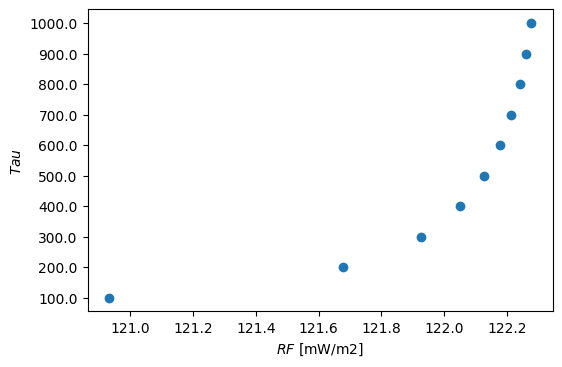

In [36]:
# Plot difference in Fluxes for cloud vs clearsky
clearFlux_arr = np.ones(len(tau)) * float(clearFlux)
fig,ax = plt.subplots(dpi=100)
ax.scatter(abs(contrailFlux - clearFlux_arr),tau)

ax.set_ylabel(ylabel= r"$Tau$")
ax.set_xlabel(xlabel = r"$RF$ [mW/m2]")

## Compare effects of standard atmospheres on RF

In [17]:
# Set-up 
rte_solver = "disort" # 1D radiative transfer solver (DIScrete ORdinaTe solver)
source = "thermal" # Absorbing on the thermal spectrum (not solar)
sza = "0" # Solar zenith angle
wavelength = "2500 80000" # Wavelength range to compute over
mol_abs_param = "reptran fine" # spectral resolution (fine/medium)
umu = "1.0" # cosine of the viewing zenith angle
output_user = "edir eglo edn eup enet esum" # The direct, global, diffuse downward, 
                                            #and diffuse upward irradiance. Net is 
                                            #global - upward, sum is global + upward.
zout = "TOA" # Top of atmosphere (where total flux is calculated)
output_process = "integrate" # Integrate over wavelength
atmosphere_file = ["midlatitude_summer", "midlatitude_winter", "subarctic_summer", "subarctic_winter", "tropics", "US-standard"] # Standard atmosphere type
ic_habit = ["solid-column", "hollow-column", "rough-aggregate", "rosette-4", "rosette-6", "plate", "droxtal", "dendrite", "spheroid"]
tau = "1500."
ic_properties = "yang"
ic_file = "ice.in"
wc_file = "cloud.in"

# Testing standard atmospheres with constant ice habit
ic_habit1 = ic_habit[0]

In [18]:
# Contrail flux
contrailFlux = np.zeros(len(atmosphere_file))
for i in range(len(atmosphere_file)):
    atmosphere_file_temp = atmosphere_file[i] # Standard atmosphere type
    print(atmosphere_file_temp)
    inputs = {'rte_solver': [rte_solver], 'source': [source], 'sza': [sza], 'wavelength': [wavelength], 'mol_abs_param': [mol_abs_param], 'umu': [umu], 'output_user': [output_user], 
         'zout': [zout], 'output_process': [output_process], 'atmosphere_file': [atmosphere_file_temp], 'ic_habit': [ic_habit1], 'ic_properties': [ic_properties], 'ic_file': [ic_file],
         'ic_modify': [tau]}
    attributes = pd.DataFrame(data = inputs)
    
    contrailFluxRaw = contrailRF(attributes,"ice")
    print(contrailFluxRaw)
    contrailFlux[i] = reformatResults(contrailFluxRaw)[-1]

midlatitude_summer
^C
[]


IndexError: list index out of range

In [ ]:
# Clearsky flux
clearFlux = np.zeros(len(atmosphere_file))
for i in range(len(atmosphere_file)):
    atmosphere_file_temp = atmosphere_file[i] # Standard atmosphere type
    print(atmosphere_file_temp)
    inputs = {'rte_solver': [rte_solver], 'source': [source], 'sza': [sza], 'wavelength': [wavelength], 'mol_abs_param': [mol_abs_param], 'umu': [umu], 'output_user': [output_user], 
         'zout': [zout], 'output_process': [output_process], 'atmosphere_file': [atmosphere_file_temp]}
    attributes = pd.DataFrame(data = inputs)
    
    clearFluxRaw = clearskyRF(attributes)
    clearFlux[i] = reformatResults(clearFluxRaw)[-1]

In [ ]:
# Plot difference in Fluxes for cloud vs clearsky

fig,ax = plt.subplots(dpi=100)
for i in range(len(atmosphere_file)):
    ax.scatter(i+1, contrailFlux[i] - clearFlux[i])
    ax.scatter(i+1, contrailFlux[i] - clearFlux[i])
    ax.scatter(i+1, contrailFlux[i] - clearFlux[i])
    ax.scatter(i+1, contrailFlux[i] - clearFlux[i])
    ax.scatter(i+1, contrailFlux[i] - clearFlux[i])
    ax.scatter(i+1, contrailFlux[i] - clearFlux[i])

ax.legend(atmosphere_file[:])
ax.set_xlabel(xlabel = r"$Standard Atm Type$")
ax.set_ylabel(ylabel = r"$RF$ [mW/m2]")

In [ ]:
lw = 1
fig,ax = plt.subplots(dpi=100)

for i in range(len(atmosphere_file)):
    ax.scatter(i, (np.mean(contrailFlux - clearFlux) - (contrailFlux[i] - clearFlux[i]))/np.mean(contrailFlux - clearFlux)*100)

ax.plot([0,1,2,3,4,5,6], np.zeros(7), 'k')
ax.legend(atmosphere_file[:])
ax.set_xlabel(xlabel = r"Standard Atm Type")
ax.set_ylabel(ylabel = r"Percentage Difference from RF Mean")

## Compare effects of ice habits on RF

In [ ]:
"""
This script calculates the contrail and clearsky flux for different ice crystal habits using a radiative transfer model.

Inputs:
- rte_solver: 1D radiative transfer solver (DIScrete ORdinaTe solver)
- source: Absorbing on the thermal spectrum (not solar)
- sza: Solar zenith angle
- wavelength: Wavelength range to compute over
- mol_abs_param: Spectral resolution (fine/medium)
- umu: Cosine of the viewing zenith angle
- output_user: The direct, global, diffuse downward, and diffuse upward irradiance. Net is global - upward, sum is global + upward.
- zout: Top of atmosphere (where total flux is calculated)
- output_process: Integration method over wavelength
- atmosphere_file: Standard atmosphere type
- ic_habit: Ice crystal habits to consider
- ic_properties: Properties of the ice crystals
- ic_file: Input file for ice properties

Outputs:
- contrailFlux: Array of contrail flux values for each ice crystal habit
- clearFlux: Array of clearsky flux values for each ice crystal habit
"""

rte_solver = "disort" 
source = "thermal" 
sza = "0" 
wavelength = "2500 80000" 
mol_abs_param = "reptran fine" 
umu = "1.0" 
output_user = "edir eglo edn eup enet esum" 
zout = "TOA" 
output_process = "integrate" 
atmosphere_file = "US-standard"
ic_habit = ["solid-column", "hollow-column", "rough-aggregate", "rosette-6", "plate", "droxtal"] 
ic_properties = "yang"
ic_file = "ice.in"

In [ ]:
# Contrail flux
contrailFlux = np.zeros(len(ic_habit))
for i in range(len(ic_habit)):
    ic_habit_temp = ic_habit[i] 
    print(ic_habit_temp)
    inputs = {'rte_solver': [rte_solver], 'source': [source], 'sza': [sza], 'wavelength': [wavelength], 'mol_abs_param': [mol_abs_param], 'umu': [umu], 'output_user': [output_user], 
         'zout': [zout], 'output_process': [output_process], 'atmosphere_file': [atmosphere_file], 'ic_habit': [ic_habit_temp], 'ic_properties': [ic_properties], 'ic_file': [ic_file]}
    attributes = pd.DataFrame(data = inputs)
    
    contrailFluxRaw = contrailRF(attributes, "ice")
    contrailFlux[i] = reformatResults(contrailFluxRaw)[-1]

In [ ]:
# Clearsky flux
clearFlux = np.zeros(len(ic_habit))
for i in range(len(ic_habit)):
    ic_habit_temp = ic_habit[i]
    print(ic_habit_temp)
    inputs = {'rte_solver': [rte_solver], 'source': [source], 'sza': [sza], 'wavelength': [wavelength], 'mol_abs_param': [mol_abs_param], 'umu': [umu], 'output_user': [output_user], 
         'zout': [zout], 'output_process': [output_process], 'atmosphere_file': [atmosphere_file]}
    attributes = pd.DataFrame(data = inputs)
    
    clearFluxRaw = clearskyRF(attributes)
    clearFlux[i] = reformatResults(clearFluxRaw)[-1]

In [ ]:
# Plot difference in Fluxes for cloud vs clearsky

fig,ax = plt.subplots(dpi=100)

ax.scatter(1, contrailFlux[0] - clearFlux[0])
ax.scatter(2, contrailFlux[1] - clearFlux[1])
ax.scatter(3, contrailFlux[2] - clearFlux[2])
ax.scatter(4, contrailFlux[3] - clearFlux[3])
ax.scatter(5, contrailFlux[4] - clearFlux[4])
ax.scatter(6, contrailFlux[5] - clearFlux[5])

ax.legend(ic_habit[:])
ax.set_xlabel(xlabel = r"Ice Habit Type")
ax.set_ylabel(ylabel = r"$RF$ [mW/m2]")

In [ ]:
lw = 1
fig,ax = plt.subplots(dpi=100)

for i in range(len(ic_habit)):
    ax.scatter(i+1, (np.mean(contrailFlux - clearFlux) - (contrailFlux[i] - clearFlux[i]))/np.mean(contrailFlux - clearFlux)*100)

ax.legend(ic_habit[:])
ax.set_xlabel(xlabel = r"Ice Habit Type")
ax.set_ylabel(ylabel = r"Percentage Difference from RF Mean")

In [ ]:
df = pd.read_csv("ice.in", sep="\s")
print(df)
df.iloc[2,2] = "A"
print(df)

df.to_csv('ice.in', sep='\t', index=False)

In [ ]:
# Optical Depth Sensitivity Study
